# 🎮 Video Game Sales — Unsupervised ML Lab
## Notebook 04 — Extras: DBSCAN & Outlier Detection

**Mål med denna notebook:**
- Experiment 2: Hitta kontroversiella spel med DBSCAN (Critic vs User Score)
- Experiment 4: Identifiera blockbusters som anomalier (DBSCAN på försäljning)
- Beskriva vad DBSCAN är och varför vi valt det
- Visualisera och tolka resultaten

---

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('../outputs/figures', exist_ok=True)

print('✅ Imports klara')

✅ Imports klara


## 1. Ladda data

In [2]:
df = pd.read_csv('../data/vgsales_features.csv')

print(f'Rader:    {len(df):,}')
print(f'Kolumner: {df.shape[1]}')
df.head(3)

Rader:    16,414
Kolumner: 25


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Rating,User_Score_scaled,NA_ratio,EU_ratio,JP_ratio,Other_ratio,Platform_Gen,Genre_encoded,Platform_Gen_encoded,Era
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,...,E,80.0,0.501151,0.350903,0.045680,0.102387,7th-gen,10,2,7th gen (03–10)
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,...,NaN,NaN,0.722664,0.088966,0.169235,0.019135,Retro,4,7,Retro (≤94)
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,...,E,83.0,0.441441,0.359234,0.106700,0.092624,7th-gen,6,2,7th gen (03–10)


## 2. Vad är DBSCAN?

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) är en 
klusteralgoritm som hittar kluster baserat på densitet — inte avstånd till ett centrum som K-Means.

### Hur fungerar den?

DBSCAN definierar två parametrar:
- **`eps`** — maxavstånd mellan två punkter för att vara "grannar"
- **`min_samples`** — minsta antal grannar för att bilda ett kluster

Varje punkt klassas som:
| Typ | Beskrivning |
|---|---|
| **Core point** | Har minst `min_samples` grannar inom `eps` |
| **Border point** | Nära en core point men har för få egna grannar |
| **Noise point (-1)** | Tillhör inget kluster — en outlier! |

### Varför DBSCAN för detta projekt?

| Fördel | Relevans |
|---|---|
| Hittar outliers automatiskt | Vi letar efter kontroversiella spel och blockbusters |
| Kräver inte att man anger K | Vi vet inte hur många kluster som finns |
| Klarar oregelbundna former | Speldata är inte perfekt klubbformad |
| Noise = intressant! | Outliers är själva poängen i våra experiment |

---

## 3. Experiment 2 — Critic vs User Score Outliers

**Fråga:** Vilka spel är mest kontroversiella — och vem har "fel", kritikerna eller spelarna?

**Approach:** Kör DBSCAN på Critic_Score och User_Score_scaled.  
Punkter långt från huvudmolnet = spel där kritiker och spelare är extremt oense.

In [3]:
# Filtrera bort rader utan betyg
df_scores = df.dropna(subset=['Critic_Score', 'User_Score_scaled']).copy()
print(f'Spel med båda betygen: {len(df_scores):,}')

X = df_scores[['Critic_Score', 'User_Score_scaled']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature-matris: {X_scaled.shape}')

Spel med båda betygen: 6,890
Feature-matris: (6890, 2)


### 3a. Hitta optimalt eps — K-Distance plot

Innan vi kör DBSCAN behöver vi välja `eps`. Ett bra sätt är att plotta 
avståndet till den k:te närmaste grannen för varje punkt — "knäet" i kurvan 
är ett bra värde för `eps`.

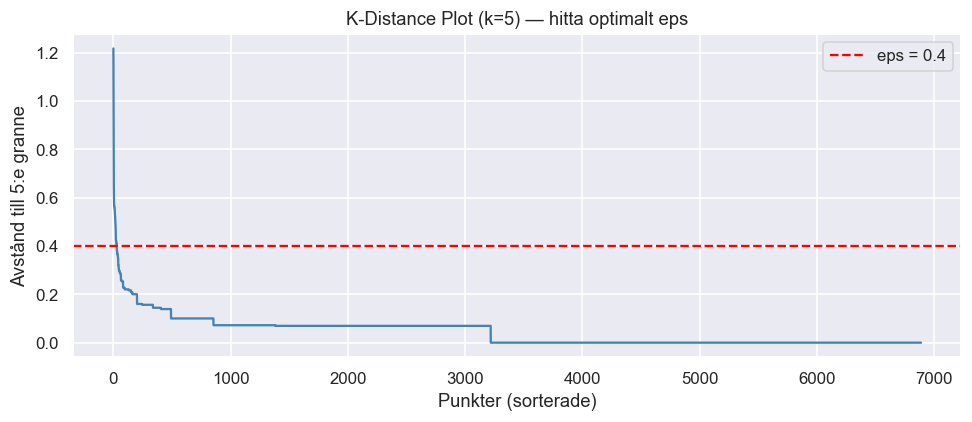

In [4]:
# K-distance plot för att hitta optimalt eps
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k-1], axis=0)[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color='steelblue', linewidth=1.5)
ax.axhline(y=0.4, color='red', linestyle='--', label='eps = 0.4')
ax.set_title(f'K-Distance Plot (k={k}) — hitta optimalt eps')
ax.set_xlabel('Punkter (sorterade)')
ax.set_ylabel(f'Avstånd till {k}:e granne')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/10_kdistance_scores.png', bbox_inches='tight', dpi=150)
plt.show()

### 3b. Kör DBSCAN

In [5]:
db = DBSCAN(eps=0.4, min_samples=10)
df_scores['DBSCAN_label'] = db.fit_predict(X_scaled)

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise    = (db.labels_ == -1).sum()
n_total    = len(db.labels_)

print(f'Kluster hittade:      {n_clusters}')
print(f'Outliers (noise):     {n_noise} ({n_noise/n_total*100:.1f}%)')
print(f'Kluster-fördelning:')
print(df_scores['DBSCAN_label'].value_counts().sort_index())

Kluster hittade:      1
Outliers (noise):     24 (0.3%)
Kluster-fördelning:
DBSCAN_label
-1      24
 0    6866
Name: count, dtype: int64


### 3c. Visualisera outliers

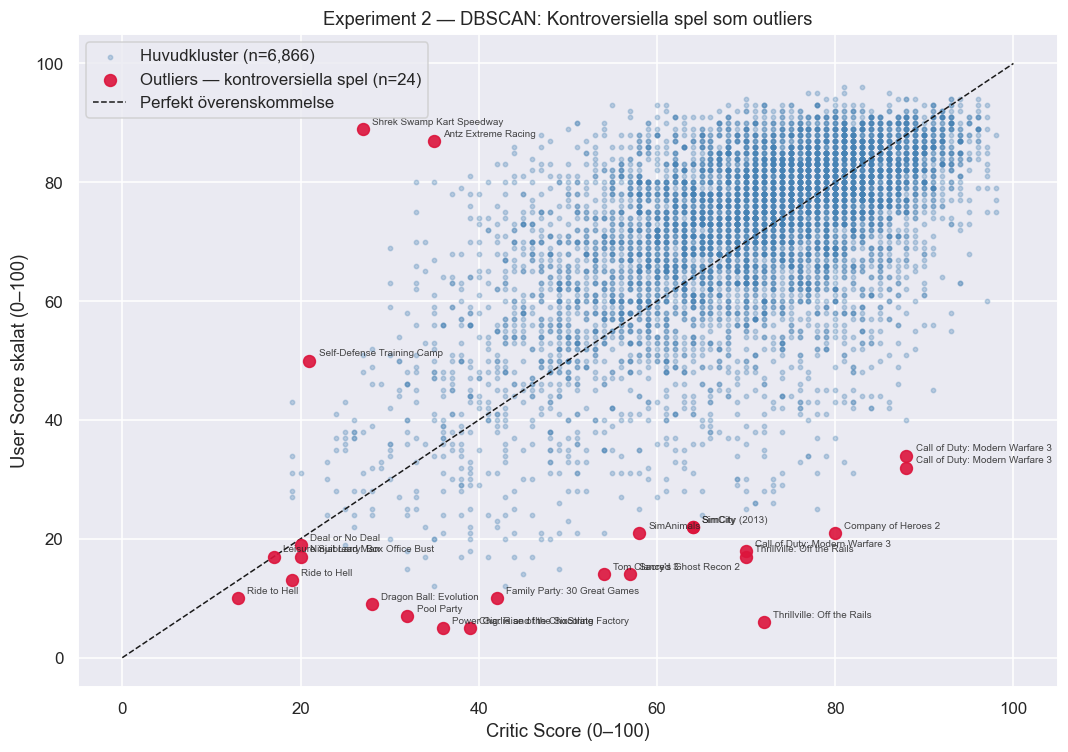

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

# Huvudkluster
normal = df_scores[df_scores['DBSCAN_label'] == 0]
ax.scatter(normal['Critic_Score'], normal['User_Score_scaled'],
           s=8, alpha=0.3, color='steelblue', label=f'Huvudkluster (n={len(normal):,})')

# Outliers
outliers = df_scores[df_scores['DBSCAN_label'] == -1]
ax.scatter(outliers['Critic_Score'], outliers['User_Score_scaled'],
           s=60, alpha=0.9, color='crimson', zorder=3,
           label=f'Outliers — kontroversiella spel (n={len(outliers)})')

# Etikettera outliers
for _, row in outliers.iterrows():
    ax.annotate(row['Name'],
                (row['Critic_Score'], row['User_Score_scaled']),
                fontsize=6.5, alpha=0.85,
                xytext=(6, 3), textcoords='offset points')

# Diagonal = perfekt överenskommelse
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfekt överenskommelse')

ax.set_xlabel('Critic Score (0–100)')
ax.set_ylabel('User Score skalat (0–100)')
ax.set_title('Experiment 2 — DBSCAN: Kontroversiella spel som outliers')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/figures/11_dbscan_scores.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi?

Outliers delas tydligt i **två grupper**:

**Ovanför diagonalen — Spelare gillar MER än kritiker:**
| Spel | Critic | User | Gap |
|---|---|---|---|
| Shrek Swamp Kart Speedway | 27 | 89 | +62 |
| Antz Extreme Racing | 35 | 87 | +52 |
| Self-Defense Training Camp | 28 | 50 | +22 |

→ Nostalgi-spel och barndomsminnen — kritiker förstår inte fansen!

**Under diagonalen — Kritiker gillar MER än spelare:**
| Spel | Critic | User | Gap |
|---|---|---|---|
| Call of Duty: MW3 | 88 | 33 | -55 |
| Company of Heroes 2 | 80 | 21 | -59 |
| Thrillville: Off the Rails | 72 | 6 | -66 |

→ Review-bombing, kontrovers vid launch, eller trött franchise-publik

> 💡 **Story-vinkel:** Outliers är inte slumpmässiga — de berättar historier  
> om nostalgi, kontroverser och klyftan mellan press och spelare.

---

In [7]:
# Tabell över alla outliers
outliers = df_scores[df_scores['DBSCAN_label'] == -1].copy()
outliers['Score_gap'] = outliers['Critic_Score'] - outliers['User_Score_scaled']
outliers['Typ'] = outliers['Score_gap'].apply(
    lambda x: '🎮 Spelare > Kritiker' if x < 0 else '📰 Kritiker > Spelare'
)

print('=== Alla 24 outliers ===\n')
print(outliers.sort_values('Score_gap', ascending=False)[
    ['Name', 'Genre', 'Platform', 'Critic_Score', 'User_Score_scaled', 'Score_gap', 'Typ']
].to_string(index=False))

=== Alla 24 outliers ===

                               Name        Genre Platform  Critic_Score  User_Score_scaled  Score_gap                  Typ
         Thrillville: Off the Rails     Strategy      PSP          72.0                6.0       66.0 📰 Kritiker > Spelare
                Company of Heroes 2     Strategy       PC          80.0               21.0       59.0 📰 Kritiker > Spelare
     Call of Duty: Modern Warfare 3      Shooter      PS3          88.0               32.0       56.0 📰 Kritiker > Spelare
     Call of Duty: Modern Warfare 3      Shooter     X360          88.0               34.0       54.0 📰 Kritiker > Spelare
         Thrillville: Off the Rails     Strategy      PS2          70.0               17.0       53.0 📰 Kritiker > Spelare
     Call of Duty: Modern Warfare 3      Shooter      Wii          70.0               18.0       52.0 📰 Kritiker > Spelare
                           Sacred 3 Role-Playing       PC          57.0               14.0       43.0 📰 Kritiker 

### 🔍 Vad berättar outliers-listan?

**Mönster bland "Kritiker > Spelare" (21 av 24):**
- **Call of Duty MW3** dyker upp 3 gånger (PS3, X360, Wii) — samma spel, samma reaktion över alla plattformar
- **Thrillville** på både PSP och PS2 — samma fenomen
- **SimCity (2013)** — review-bombad pga alltid-online-krav vid launch
- **Ride to Hell** — ett av tidernas sämst recenserade spel (13–19 critic) men användarna är ändå lite snällare

**Mönster bland "Spelare > Kritiker" (3 av 24):**
- **Shrek & Antz** — tydlig nostalgi/barndomseffekt
- **Self-Defense Training Camp** — nischad publik som älskar det

**Stor insikt:**
> Review-bombing är vanligare än nostalgi-röstning i detta dataset.  
> Spelare straffar hårdare än de belönar — när de är missnöjda hörs det!

---
## 4. Experiment 4 — Blockbusters vs Long Tail

In [8]:
features = ['Global_Sales', 'NA_ratio', 'EU_ratio', 'JP_ratio']
df_sub = df[features + ['Name', 'Genre', 'Platform', 'Year_of_Release']].dropna().copy()

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(df_sub[features])

print(f'Dataset för experiment 4: {len(df_sub):,} spel')
print(f'Features: {features}')

Dataset för experiment 4: 16,413 spel
Features: ['Global_Sales', 'NA_ratio', 'EU_ratio', 'JP_ratio']


### 4a. Hitta optimalt eps — K-Distance plot

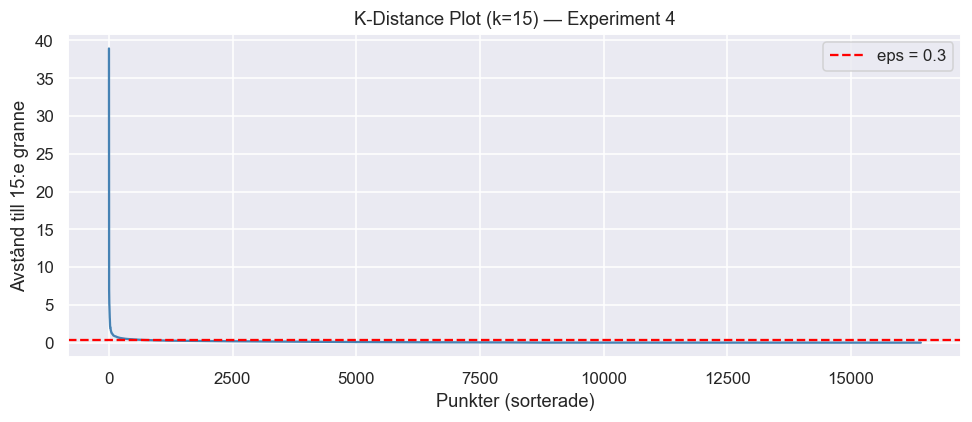

In [9]:
k = 15
nbrs2 = NearestNeighbors(n_neighbors=k).fit(X2_scaled)
distances2, _ = nbrs2.kneighbors(X2_scaled)
k_distances2 = np.sort(distances2[:, k-1], axis=0)[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances2, color='steelblue', linewidth=1.5)
ax.axhline(y=0.3, color='red', linestyle='--', label='eps = 0.3')
ax.set_title(f'K-Distance Plot (k={k}) — Experiment 4')
ax.set_xlabel('Punkter (sorterade)')
ax.set_ylabel(f'Avstånd till {k}:e granne')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/12_kdistance_blockbusters.png', bbox_inches='tight', dpi=150)
plt.show()

### 4b. Kör DBSCAN — testa olika eps

In [10]:
# Testa tre olika eps-värden
for eps_val in [0.3, 0.5, 0.8]:
    db_test = DBSCAN(eps=eps_val, min_samples=15)
    labels_test = db_test.fit_predict(X2_scaled)
    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    n_noise = (labels_test == -1).sum()
    print(f'eps={eps_val}: kluster={n_clusters}, outliers={n_noise} ({n_noise/len(labels_test)*100:.1f}%)')

eps=0.3: kluster=4, outliers=641 (3.9%)
eps=0.5: kluster=2, outliers=197 (1.2%)
eps=0.8: kluster=2, outliers=78 (0.5%)


### 4c. Kör DBSCAN med eps=0.5

In [11]:
db2 = DBSCAN(eps=0.5, min_samples=15)
df_sub['DBSCAN_label'] = db2.fit_predict(X2_scaled)

n_clusters = len(set(db2.labels_)) - (1 if -1 in db2.labels_ else 0)
n_noise    = (db2.labels_ == -1).sum()

print(f'Kluster hittade: {n_clusters}')
print(f'Outliers:        {n_noise} ({n_noise/len(df_sub)*100:.1f}%)')
print(f'\nKluster-fördelning:')
print(df_sub['DBSCAN_label'].value_counts().sort_index())

Kluster hittade: 2
Outliers:        197 (1.2%)

Kluster-fördelning:
DBSCAN_label
-1      197
 0    16194
 1       22
Name: count, dtype: int64


### 4d. Vad är i kluster 1 och bland outliers?

In [12]:
# Vad är kluster 1?
print('=== Kluster 1 — Mellanstora blockbusters? ===')
print(df_sub[df_sub['DBSCAN_label'] == 1].sort_values(
    'Global_Sales', ascending=False)[
    ['Name', 'Genre', 'Platform', 'Global_Sales']
].to_string(index=False))

print()

# Top outliers
print('=== Top 15 outliers efter Global Sales ===')
print(df_sub[df_sub['DBSCAN_label'] == -1].sort_values(
    'Global_Sales', ascending=False)[
    ['Name', 'Genre', 'Platform', 'Global_Sales']
].head(15).to_string(index=False))

=== Kluster 1 — Mellanstora blockbusters? ===
                                               Name        Genre Platform  Global_Sales
                          Spy Hunter / Super Sprint       Racing      GBA          0.02
                         Room Zoom: Race for Impact       Racing       XB          0.02
                            Stake: Fortune Fighters     Fighting       XB          0.02
                                Serious Sam Advance      Shooter      GBA          0.02
                                           Cold War      Shooter       XB          0.02
                   Steel Battalion: Line of Contact   Simulation       XB          0.02
                                  NBA Starting Five       Sports       XB          0.02
Disney's Magical Quest 3 Starring Mickey and Donald       Action      GBA          0.02
    Carmen Sandiego: The Secret of the Stolen Drums       Action       XB          0.02
                 Ed, Edd n Eddy: The Mis-Edventures     Platform       XB 

### 🔍 Vad hittade DBSCAN?

| Grupp | Antal | Beskrivning |
|---|---|---|
| **Kluster 0** | 16,194 | "Vanliga" spel — long tail-massan |
| **Kluster 1** | 22 | Extremt lågförsäljande nischspel (alla 0.02M) |
| **Outliers (-1)** | 197 | Blockbusters — för unika för att passa in |

**Insikt om outliers:**
- Topp 15 är nästan helt **Nintendo-titlar**
- **Wii Sports (82.53M)** är extremt avvikande — nästan dubbelt nästa
- **Retro-titlar** (NES/GB) dyker upp trots sin ålder — tidlösa försäljningssiffror

> 💡 DBSCAN bekräftar **Long Tail-teorin** i spelmarknaden:  
> ~99% av spelen är "vanliga" och ett fåtal blockbusters är statistiska anomalier.  
> De bäst säljande spelen är inte ett kluster — de är undantag från regeln!

---

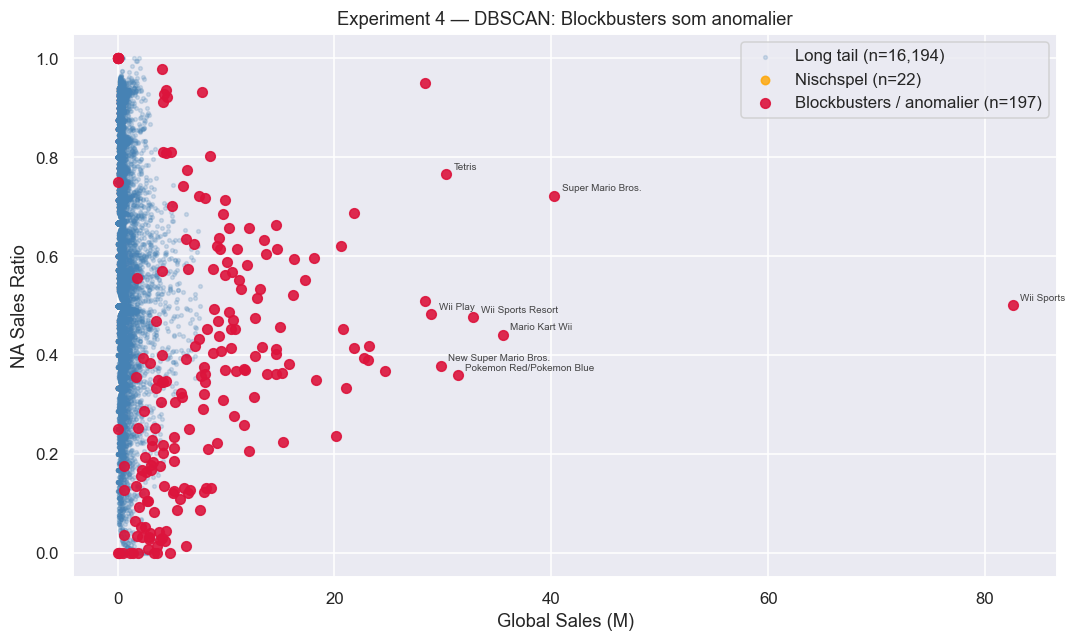

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

normal  = df_sub[df_sub['DBSCAN_label'] == 0]
cluster1 = df_sub[df_sub['DBSCAN_label'] == 1]
outlier = df_sub[df_sub['DBSCAN_label'] == -1]

ax.scatter(normal['Global_Sales'], normal['NA_ratio'],
           s=6, alpha=0.2, color='steelblue', label=f'Long tail (n={len(normal):,})')
ax.scatter(cluster1['Global_Sales'], cluster1['NA_ratio'],
           s=30, alpha=0.8, color='orange', label=f'Nischspel (n={len(cluster1)})')
ax.scatter(outlier['Global_Sales'], outlier['NA_ratio'],
           s=40, alpha=0.9, color='crimson', zorder=3,
           label=f'Blockbusters / anomalier (n={len(outlier)})')

# Etikettera top blockbusters
top = outlier.sort_values('Global_Sales', ascending=False).head(8)
for _, row in top.iterrows():
    ax.annotate(row['Name'],
                (row['Global_Sales'], row['NA_ratio']),
                fontsize=6.5, alpha=0.85,
                xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Global Sales (M)')
ax.set_ylabel('NA Sales Ratio')
ax.set_title('Experiment 4 — DBSCAN: Blockbusters som anomalier')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/13_dbscan_blockbusters.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi i plotten?

| Observation | Detalj |
|---|---|
| **Wii Sports helt ensam** | 82.53M — så extrem att den inte har grannar |
| **Tetris hög NA-ratio (77%)** | Såldes nästan bara i NA — kulturellt fenomen |
| **Super Mario Bros. 72% NA** | NES-eran dominerades av NA-marknaden |
| **Röda punkter nära noll** | Även "små" blockbusters är outliers jämfört med long tail |
| **Nischspel (orange)** | 22 spel med 0.02M — för unika regionalt för att passa in |

> 💡 **Long Tail-teorin bekräftad:**  
> 98.8% av spelen lever i den täta massan nära noll.  
> Blockbusters är inte ett segment — de är statistiska undantag.

---
## 5. Sammanfattning — DBSCAN

```markdown
| | Experiment 2 | Experiment 4 |
|---|---|---|
| **Features** | Critic Score, User Score | Global Sales, Regionala ratios |
| **eps** | 0.4 | 0.5 |
| **min_samples** | 10 | 15 |
| **Kluster** | 1 | 2 |
| **Outliers** | 24 (0.3%) | 197 (1.2%) |
| **Vad hittades** | Kontroversiella spel | Blockbusters + nischspel |

### Varför DBSCAN var rätt val:
- Vi visste inte i förväg hur många kluster som fanns → K-Means passar inte
- Outliers **var** det intressanta → DBSCAN identifierar dem automatiskt
- Speldata är inte jämnt fördelad → densitetsbaserad approach fungerar bättre
```

---

In [14]:
df_scores.to_csv('../data/vgsales_dbscan_scores.csv', index=False)
df_sub.to_csv('../data/vgsales_dbscan_blockbusters.csv', index=False)
print('✅ Sparat:')
print('   ../data/vgsales_dbscan_scores.csv')
print('   ../data/vgsales_dbscan_blockbusters.csv')
print(f'\n📊 Figurer sparade i ../outputs/figures/')
print('   10_kdistance_scores.png')
print('   11_dbscan_scores.png')
print('   12_kdistance_blockbusters.png')
print('   13_dbscan_blockbusters.png')

✅ Sparat:
   ../data/vgsales_dbscan_scores.csv
   ../data/vgsales_dbscan_blockbusters.csv

📊 Figurer sparade i ../outputs/figures/
   10_kdistance_scores.png
   11_dbscan_scores.png
   12_kdistance_blockbusters.png
   13_dbscan_blockbusters.png
